In [1]:
import os
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx
from tqdm import tqdm

import dcor
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

ModuleNotFoundError: No module named 'plotUtils'

In [2]:
COLOR_MAP = {
                'darkgreen': "Stable Node",
                'red': "Unstable Node",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [3]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -20 / params['gamma']
maxval = 20 / params['gamma']
grid_res = 1000
nInits = 20

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)


t_start = 1000
t_end = T

In [5]:
# Reading connectivity matrix from OSF data

AALMAp = pd.read_csv("./data/AAL_regions.csv", sep=";")
ROI = AALMAp['ROI number'].to_numpy()
print(ROI)
ROI_tags = AALMAp['ROI name'].to_numpy()

A = pd.read_csv("./S001.csv", header=None).to_numpy()
A = (A + A.T) / 2

# creating a sub graph from right hemisphere ROIs

RightROIs = ROI[1 :: 2] - 1
params['N'] = nNodes = 10

RandomROIS = RightROIs[15 : 15 + nNodes] # np.array(random.sample(list(RightROIs), k=nNodes))
RandomROI_tags = ROI_tags[RandomROIS]
ASubgraph = A[RandomROIS, :][:, RandomROIS]

# Scaling
normalization_factor = np.max(np.abs(ASubgraph.sum(axis=1)))
ASubgraph /= normalization_factor

Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

params['Abar'] = Abar = (Dnet.T @ ASubgraph) @ Dnet

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]


In [9]:
tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

params['Kglob'] = 2
_modnodes = [3, 4, 5]

In [6]:
# Initialization
random.seed(0)
xInit = np.random.uniform(minval, maxval, (2 * nNodes, grid_res))

In [7]:
# Setting save dir paths
root_dir = "./results/fp/"

save_str = datetime.datetime(2024, 3, 20)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}-v4"

save_dir = os.path.join(root_dir, sub_dir)

print(f"Creating dir to save results:: {save_dir}")
os.makedirs(save_dir, exist_ok = True)

Creating dir to save results:: ./results/fp/exp-2024-3-20-v4


Running evaluation for (2.500, 4.400)


100%|██████████| 500/500 [17:57<00:00,  2.15s/it]


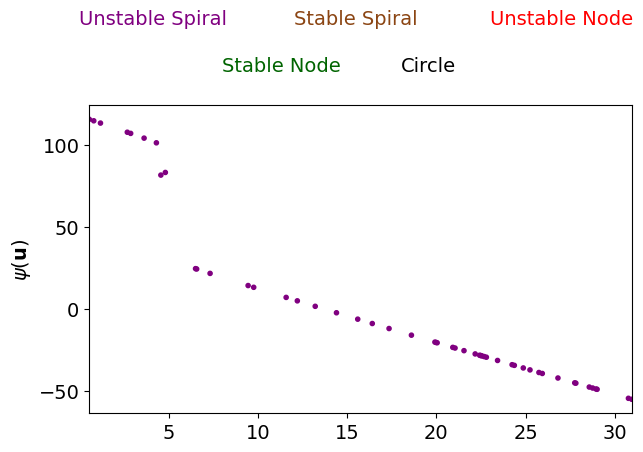

Running evaluation for (2.500, 16.500)


100%|██████████| 500/500 [18:21<00:00,  2.20s/it]


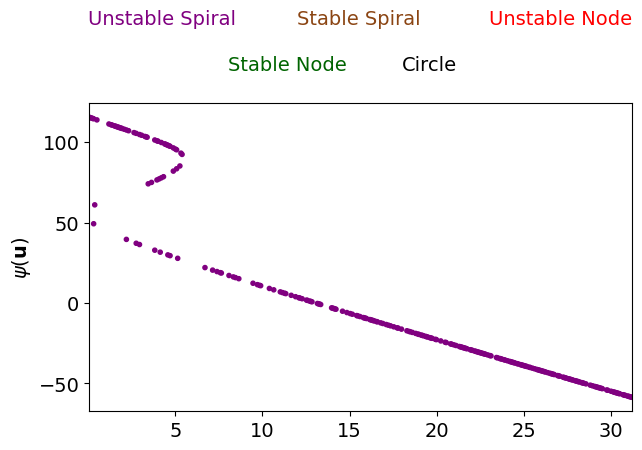

Running evaluation for (7.500, 4.400)


  2%|▏         | 12/500 [00:27<18:55,  2.33s/it]


KeyboardInterrupt: 

In [10]:
sigma_permute = np.array([[2.5, 4.4], [2.5, 16.5], [7.5, 4.4], [7.5, 16.5], [16.5, 4.4], [16.5, 16.5]])

i_min = 0; i_max = 0.5; i_steps = 500
i_values = i_min + np.arange(0, i_steps) / (i_steps - 1) * (i_max - i_min)

for  n, sigma_ in enumerate(sigma_permute):
    sigmae = sigma_[0]
    sigmai = sigma_[1]


    print(f"Running evaluation for ({sigmae:.3f}, {sigmai:.3f})")
    sigma = np.ones(2 * nNodes)
    sigma[0 :: 2] *= sigmae
    sigma[1 :: 2] *= sigmai

    for node in _modnodes:
        sigma[2 * node] = 2.5
        sigma[2 * node + 1] = 4.4
    
    params['sigma'] = sigma
    
    FPvar = []
    FPs = []
    FPType = []
    
    file_str_k = f"sige_{sigmae:.3f}_sigi_{sigmai:.3f}_K_{params['Kglob']:.3f}"
    file_name = os.path.join(save_dir, file_str_k + '.pkl')

    for i in tqdm(range(i_steps)):
        params['i_mod'] = i_values[i] / params['gamma']

        fp_dict = calc_fixed_points(grid_points=xInit, _modnodes=_modnodes, nInits=nInits, **params)
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

        fps = fp_dict['fps'].T   
        fp_type = eig_dict['types']

        if len(fp_type) == 0:
            continue
            
        for fp, fp_color in zip(fps, fp_type):
            FPvar.append(i_values[i])
            FPs.append(fp)
            FPType.append(fp_color)
            
    plot_fps = {'FPVar': FPvar, 'FPs': FPs, 'FPType': FPType }

    with open(file_name, 'wb') as file:
        pickle.dump(plot_fps, file)

    DF = dimreduction(plot_fps, xVar='I', **params)

    textDelt = max(DF['U']/ params['gamma']) * 0.5
    plt.figure(figsize=(7, 4))
    plt.scatter(np.array(plot_fps['FPVar']) / params['gamma'], DF['U'] / params['gamma'], c=DF['FPType'], marker='.')
    plt.ylabel(r'$\psi(\mathbf{u})$')
    plt.text(0, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['purple'], c='purple')
    plt.text(23, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['red'], c='red')
    plt.text(18, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['black'], c='black')
    plt.text(8, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['darkgreen'], c='darkgreen')
    plt.text(12, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['saddlebrown'], c='saddlebrown')
    plt.xlim(min(np.array(plot_fps['FPVar'])) / params['gamma'], max(np.array(plot_fps['FPVar'])) / params['gamma'])
    plt.savefig(os.path.join(save_dir, file_str_k + '.png'), bbox_inches='tight')
    plt.show()
    

In [ ]:
weight_arr = ASubgraph[np.triu_indices(nNodes, k=1)].flatten()

weight_acc = []

k_min = -2; k_max = 2; k_steps = 10000
eval_k = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

for K in eval_k:
    weight_acc += list(weight_arr * K)

plt.figure(figsize=(6, 4))
h = plt.hist(weight_acc, bins=50, density=True, color='k')
plt.text(-1, 12, r"$K_{glob} \in [-2, 2]$")
plt.text(-1, 9, r"$p_{ij} \in [0, 1]$")
plt.xlabel(r'$K_{eff} = K_{glob} \times p_{jk}$')
plt.ylabel(r'Count')